# Numerical Methods II exam
Feb 26, 2026 - Nathasya Christien

In [ ]:
# Import needed packages
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable

# (a) Discretizing the problem

With Taylor expansion, the second order scheme is the centered in time/space one:
$$ f'(x_j) = \frac{f(x_{j+1}) - f(x_{j-1})}{2\Delta x} + \mathcal{O}(\Delta x^2) $$
$$ f'(x^n) = \frac{f(x^{n+1}) - f(x^{n-1})}{2\Delta t} + \mathcal{O}(\Delta t^2) $$

Applying this to Eq. (1) results in the discretized equation:
$$\frac{\psi_j^{n+1} - \psi_j^{n-1}}{2\Delta t} = -u \frac{\psi_{j+1}^{n} - \psi_{j-1}^{n}}{2\Delta x}$$

and by arranging it, we obtain the explicit scheme:
$$ \psi_j^{n+1}= \psi_j^{n-1} - \frac{u \Delta t}{\Delta x} (\psi_{j+1}^{n} - \psi_{j-1}^{n}) $$

# (b) Scheme stability

Generally, we wish our numerical solution to converge to the true (analytical) solution. The proposed numerical scheme is consistent as it is derived using Taylor expansion, ensuring it will tend to analytical solution with refinement of time and space step size. However, consistency is not enough to guarantee convergence. By Lax theorem, we also need stability as the necessary condition for the scheme's convergence. Moreover, for linear method, this is also a sufficient condition.

As an implication for a conditionally stable scheme, we have to choose appropriate grid size and time step size to ensure our numerical solution is stable, thus converge to the true solution.

# (c) Stability analysis

- First, we apply the ansatz such that our numerical solution has a wave-like solution $\psi_j^n = A^n e^{ijk\Delta x}$ for any wave number $k$.
- Solve the equation, such that we obtain the explicit expression of $A$ which depends on the problem parameters (e.g constant $u$ in linear advection) and $\Delta x$, $\Delta t$.
- Look for the condition, such that $|A| \leq 1$. This means that the solution will not blow up in time. Usually, given problem parameters and chosen $\Delta x$, we can choose appropriate $\Delta t$ with this condition.

# (d) Solving linear advection without filter

In [ ]:
class Advection:
    ''' 
    Solve linear advection with CTCS scheme and apply RA or RAW filter if specified. 
    Default filter parameters are set such that the filter is not active.
    '''
    def __init__(self, 
                 phi0 : Callable[[np.array], np.array], 
                 u : float, c: float, 
                 dx : float, x0 : float, x1 : float,
                 alpha : float = 0.0,
                 beta : float = 1.0):
        
        # Save numerical parameters
        self.phi0 = phi0
        self.u = u
        self.c = c
        self.dx = dx
        self.dt = c * dx / u # based on definition of Courant number

        # Save filter info
        self.alpha = alpha
        self.beta = beta

        # Define space domain
        nx = int((x1 - x0) / dx) + 1
        self.xs = np.linspace(x0, x1, nx)
    
    def ftfs(self, phi_now: np.array) -> np.array:
        return (1 + self.c) * phi_now - self.c * np.roll(phi_now, -1)
    
    def ftbs(self, phi_now: np.array) -> np.array:
        return (1 - self.c) * phi_now + self.c * np.roll(phi_now, 1)

    def ctcs(self, phi_old: np.array, phi_now: np.array) -> np.array:
        return phi_old - self.c * (np.roll(phi_now, -1) - np.roll(phi_now, 1))

    def plot_phi(self, phi: np.array, time: float):
        label = rf'$t={int(time)}$'
        plt.plot(self.xs, phi, label=label)
    
    def solve(self, t0: float, t1: float, display_time: float, add_title=None):
        # Initialize time and streamfunction
        t = t0
        phi_old = self.phi0(self.xs)

        # Plot initial condition
        plt.figure(figsize=(12, 6))
        self.plot_phi(phi_old, 0)

        # Update streamfunction by using the leap-frog scheme
        # for the first time step
        if self.u > 0:
            phi_now = self.ftbs(phi_old)
        else:
            phi_now = self.ftfs(phi_old)
        t += self.dt

        # Iterate and apply numerical scheme
        while (t < t1):

            # Update time
            t += self.dt
           
            # Update streamfunction by using the upwind scheme
            phi_new = self.ctcs(phi_old, phi_now)

            # Swap values and apply filter
            d = self.alpha * (phi_old + phi_new - 2.0 * phi_now)
            phi_old = phi_now + self.beta * d
            phi_now = phi_new + (1 - self.beta) * d
            
            # Plot given condition
            if self.beta == 1: # RA filter or no filter at all
                if ((t - t0) % display_time) < self.dt:
                    self.plot_phi(phi_now, t)
            else: # RAW filter
                if ((t - self.dt - t0) % display_time) < self.dt:
                    self.plot_phi(phi_old, t - self.dt)

        # Decorate plot
        if add_title != None:
            plt.suptitle(rf'Solution of $\psi$ - {add_title}')
        else:
            plt.suptitle(r'Solution of $\psi$')
        plt.title(rf'$c={self.c :.2f}, \alpha = {self.alpha :.2f}, \beta = {self.beta: .2f}, \Delta t={self.dt :.2f}, u={self.u}$')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.xlabel('$x$')
        plt.grid()
        plt.tight_layout()

In [3]:
def fill_array(out: np.array, x: np.array, bounds: list[float, float], f) -> np.array:
    idxs = (x >= bounds[0]) & (x < bounds[1])
    out[idxs] = f(x[idxs])
    return out

# Define streamfunction initial condition, phi(x, 0)
def phi0 (x: np.array) -> np.array:
    out = np.zeros_like(x)
    out = fill_array(out, x, [65.0, 85.0], lambda _ : 5)
    out = fill_array(out, x, [85.0, 105.0], lambda _ : 10)
    return out

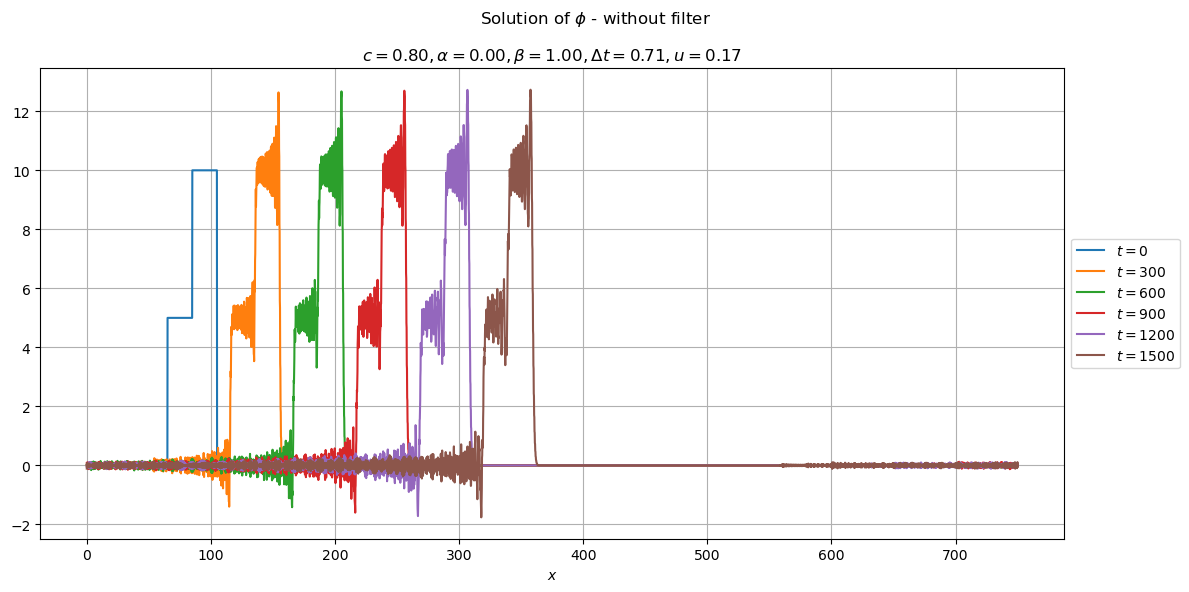

In [4]:
# Define space and time domain, and velocity
x0, x1  = 0, 750
dx      = 0.15
t0, t1  = 0, 1_501 
u       = 0.17
dsp     = 300           # display time

# Define Courant number of choice
c       = 0.8

# Solve advection problem without filter
adv = Advection(phi0=phi0, u=u, c=c, dx=dx, x0=x0, x1=x1)
adv.solve(t0, t1, display_time=dsp, add_title='without filter')

**Remarks**: I set Courant number that is less or equal than one to satify CFL and compute the corresponding $\Delta t$ to be used in the simulation.

# (e) Solving linear advection with filter

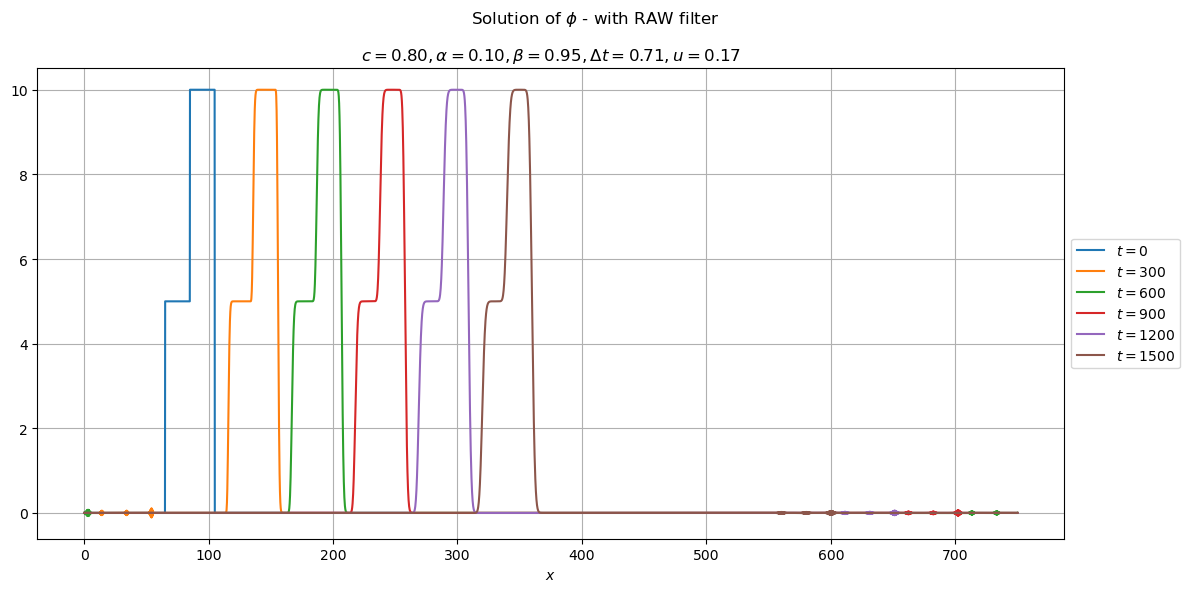

In [5]:
# Solve advection problem with RAW filter
adv = Advection(phi0=phi0, u=u, c=c, dx=dx, x0=x0, x1=x1, alpha=0.1, beta=0.95)
adv.solve(t0, t1, display_time=dsp, add_title='with RAW filter')

**Remarks**: Here I applied RAW filter, such that we perform correction to previous time steps in the calculation. This is to mitigate the computational mode in the second order scheme, which propagates in the opposite direction of the physical solution and results in the wiggle-like error. In fact, the filter mimics diffusion if we observe the formula, so it filters noises at previous time steps by diffusing it.

# (f) Adding diffusion to linear advection problem

## New scheme and non-linearity

The new problem now is
$$ \frac{\partial \psi}{\partial t} + u \frac{\partial \psi}{\partial x} = K \frac{\partial^2 \psi}{\partial x^2} $$
with constant $K$ as diffusivity parameter.

By applying second order to the second derivative, the new discretized equation is
$$\frac{\psi_j^{n+1} - \psi_j^{n-1}}{2\Delta t} + u \frac{\psi_{j+1}^{n} - \psi_{j-1}^{n}}{2\Delta x} = K \left( \frac{\psi_{j+1}^{n-1} - 2 \psi_j^{n-1} + \psi_{j-1}^{n-1}}{\Delta x^2} \right)$$
to solve the problem.

In non-linear problem, we often encounter large gradients which interferes the scheme stability. This is why adding diffusion term is important to filter out the formation of sharp gradients.

Moreover, Von Neumann stability analysis is only a necessary condition for the stability of a non-linear difference equation. Adding diffusion term with appropriate value (e.g diffusion constant) can further help mitigating this issue.

## Simulation

In [ ]:
class AdvectionDiffusion:
    ''' 
    Solve linear advection-diffusion with CTCS scheme and apply RA or RAW filter if specified.
    Default filter parameters are set such that the filter is not active.
    '''
    def __init__(self, 
                 phi0 : Callable[[np.array], np.array], 
                 u : float, c: float, k : float,
                 dx : float, x0 : float, x1 : float,
                 alpha : float = 0.0,
                 beta : float = 1):
        
        # Save numerical parameters
        self.phi0 = phi0
        self.u = u
        self.k = k
        self.dx = dx
        self.dt = min([c * dx / u, abs(c) * dx ** 2 / (2*k)]) # based on definition of Courant number
        self.dc = k * self.dt / dx ** 2
        self.c = u * self.dt / dx

        # Save filter info
        self.alpha = alpha
        self.beta = beta

        # Define space domain
        nx = int((x1 - x0) / dx) + 1
        self.xs = np.linspace(x0, x1, nx)
    
    def ftcs_diff(self, phi_now: np.array) -> np.array:
        return phi_now - 0.5 * self.c * (np.roll(phi_now, -1) - np.roll(phi_now, 1)) + \
        self.dc * (np.roll(phi_now, -1) - 2 * phi_now + np.roll(phi_now, 1))
    
    def ctcs_diff(self, phi_old: np.array, phi_now: np.array) -> np.array:
        return phi_old - self.c * (np.roll(phi_now, -1) - np.roll(phi_now, 1)) + \
        2 * self.dc * (np.roll(phi_old, -1) - 2 * phi_old + np.roll(phi_old, 1))

    def plot_phi(self, phi: np.array, time: float):
        label = rf'$t={int(time)}$'
        plt.plot(self.xs, phi, label=label)
    
    def solve(self, t0: float, t1: float, display_time: float, add_title=None):
        # Initialize time and stream function
        t = t0
        phi_old = self.phi0(self.xs)

        # Plot initial condition
        plt.figure(figsize=(12, 6))
        self.plot_phi(phi_old, 0)

        # Update stream function by FTCS
        phi_now = self.ftcs_diff(phi_old)
        t += self.dt

        # Iterate and apply numerical scheme
        while (t < t1):

            # Update stream function by using CTCS
            phi_new = self.ctcs_diff(phi_old, phi_now)

            # Swap values and apply filter
            d = self.alpha * (phi_old + phi_new - 2.0 * phi_now)
            phi_old = phi_now + self.beta * d
            phi_now = phi_new + (1 - self.beta) * d

            # Update time
            t += self.dt
            
            # Plot given condition
            if self.beta == 1: # RA filter or no filter at all
                if ((t - t0) % display_time) < self.dt:
                    self.plot_phi(phi_now, t)
            else: # RAW filter (plot corrected last value)
                if ((t - self.dt - t0) % display_time) < self.dt:
                    self.plot_phi(phi_old, t - self.dt)

        # Decorate plot
        if add_title != None:
            plt.suptitle(rf'Solution of $\psi$ - {add_title}')
        else:
            plt.suptitle(r'Solution of $\psi$')
        plt.title(rf'$\Delta t={self.dt :.3f}, \Delta x={self.dx :.3f}, u={self.u}, K={self.k :.3f}$')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.grid()
        plt.xlabel('$x$')
        plt.tight_layout()

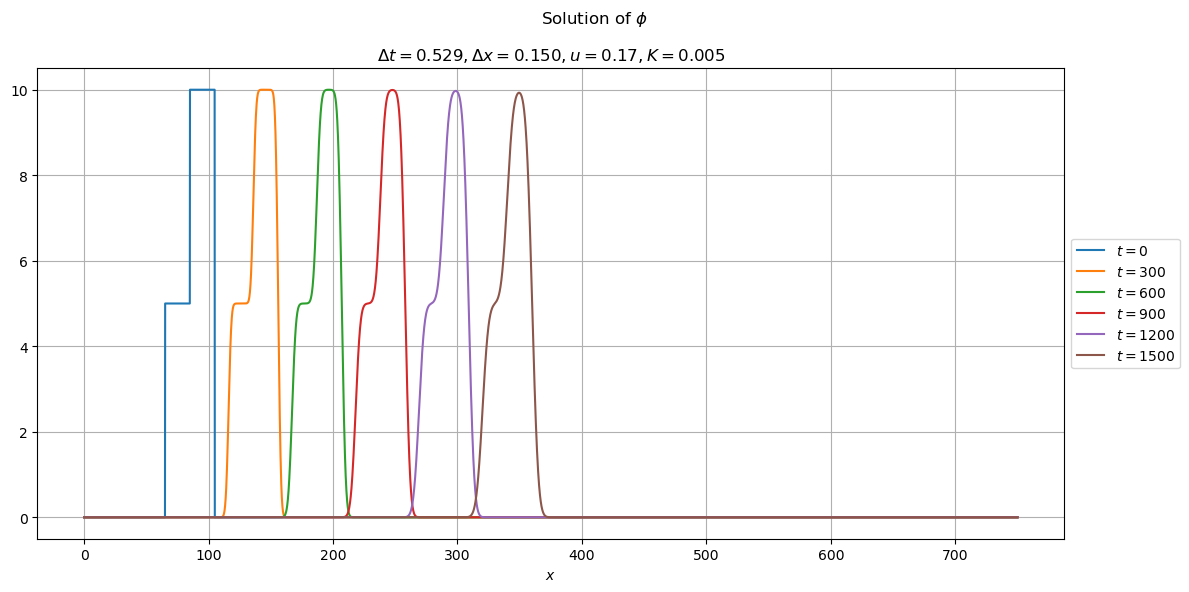

In [7]:
# Define diffusion parameter
k       = 0.005

# Solve advection-diffusion problem 
adv_diff = AdvectionDiffusion(phi0=phi0, u=u, dx=dx, x0=x0, x1=x1, c=0.6, k=k)
adv_diff.solve(t0, t1, display_time=dsp)

**Remarks**: In this simulation, I didn't apply any filter. However, with the added diffusion term, the wiggle-like error is not observed anymore as the diffusion filters it out.

Note that I also lowered my choice of $\Delta t$ as the stability is now affected by the diffusion problem, which lowers the stability window.